In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"../data/processed/feature_engineered_data.csv")
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,...,RollingMean_7,RollingMean_14,RollingMean_30,RollingStd_7,CompetitionAgeMonths,PromoDurationMonths,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,3,2013-02-06,6140,693,1,1,0,0,226264,...,5388.428571,5346.071429,5103.833333,1109.382990,53.966667,0.0,0.866025,0.5,0.433884,-0.900969
1,1,4,2013-02-07,5499,675,1,1,0,0,318919,...,5733.428571,5399.357143,5124.166667,851.378658,54.000000,0.0,0.866025,0.5,-0.433884,-0.900969
2,1,5,2013-02-08,5681,630,1,1,0,0,440864,...,5861.714286,5383.571429,5163.233333,707.864797,54.033333,0.0,0.866025,0.5,-0.974928,-0.222521
3,1,6,2013-02-09,5370,656,1,0,0,0,779012,...,6000.571429,5390.928571,5203.066667,512.408319,54.066667,0.0,0.866025,0.5,-0.781831,0.623490
4,1,1,2013-02-11,4409,599,1,0,0,0,179504,...,5963.000000,5403.428571,5215.500000,551.966786,54.133333,0.0,0.866025,0.5,0.781831,0.623490


In [3]:
df["Date"].min(), df["Date"].max()

('2013-01-31', '2015-07-17')

In [4]:
df_model = df.copy()

## Data Splitting

In [5]:
cutoff_date = "2015-06-01"

train_df = df_model[df_model["Date"] < cutoff_date]
test_df  = df_model[df_model["Date"] >= cutoff_date]

In [6]:
X_train = train_df.drop(columns=["Sales", "Date", "Customers", "Id"])
y_train = train_df["Sales"]

X_test_date = test_df["Date"]

X_test = test_df.drop(columns=["Sales", "Date", "Customers", "Id"])
y_test = test_df["Sales"]

In [7]:
print(X_train.shape)
print(X_test.shape)

(752277, 39)
(45191, 39)


In [8]:
import joblib
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "../artifacts/features.pkl")

['../artifacts/features.pkl']

## Base Model

In [9]:
from sklearn.linear_model import LinearRegression
import time

baseline_model = LinearRegression()
start = time.time()
baseline_model.fit(X_train, y_train)
baseline_train_time = time.time() - start

In [10]:
baseline_pred = baseline_model.predict(X_test)
print(baseline_pred[:5])

[7634.77785381 5823.77023466 5320.47296869 5930.03327975 3701.72086605]


In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, baseline_pred)
rmse = root_mean_squared_error(
    y_test,
    baseline_pred
)
r2 = r2_score(y_test, baseline_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 858.49
RMSE: 1214.24
R²  : 0.8511


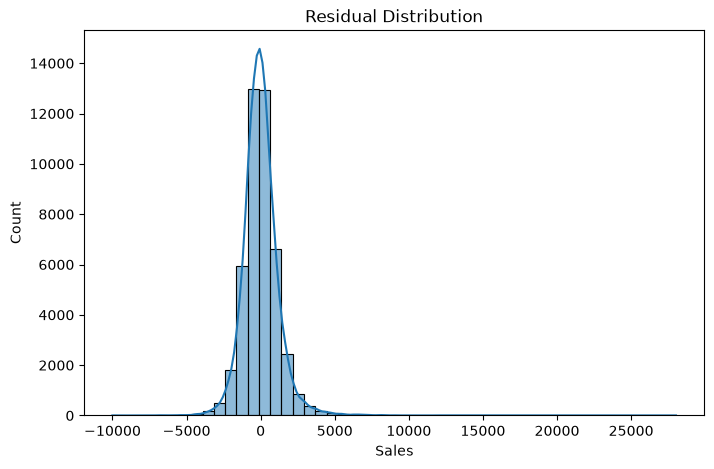

In [12]:
residuals = y_test - baseline_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [13]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": baseline_model.coef_
})

coef.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
3,Promo,1770.244095
24,IsMonthEnd,1108.429960
23,IsMonthStart,684.967840
38,DayOfWeek_cos,599.153746
35,Month_sin,543.593178
5,SchoolHoliday,248.773434
21,WeekOfYear,29.347451
18,Week,29.347451
20,DayOfYear,14.036806
7,Assortment,9.633673


## Some of Advanced Model

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time

In [15]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2, train_time, pred

In [16]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_mae, dt_rmse, dt_r2, dt_time, dt_pred = evaluate_model(
    dt,
    X_train,
    y_train,
    X_test,
    y_test
)

In [17]:
rf = RandomForestRegressor(
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)

rf_mae, rf_rmse, rf_r2, rf_time, rf_pred = evaluate_model(
    rf,
    X_train,
    y_train,
    X_test,
    y_test
)

In [18]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)
xgb_mae, xgb_rmse, xgb_r2, xgb_time, xgb_pred = evaluate_model(
    xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

## Model Evaluation and Comparison

In [19]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2":[
        r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ],

    "Training Time":[
        baseline_train_time,
        dt_time,
        rf_time,
        xgb_time
    ]

})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2,Training Time
3,XGBoost,614.019775,864.026245,0.924602,57.062458
2,Random Forest,713.694621,1019.094040,0.895110,58.070135
1,Decision Tree,775.250568,1111.923440,0.875131,15.029686
0,Linear Regression,858.490014,1214.238095,0.851094,5.106471


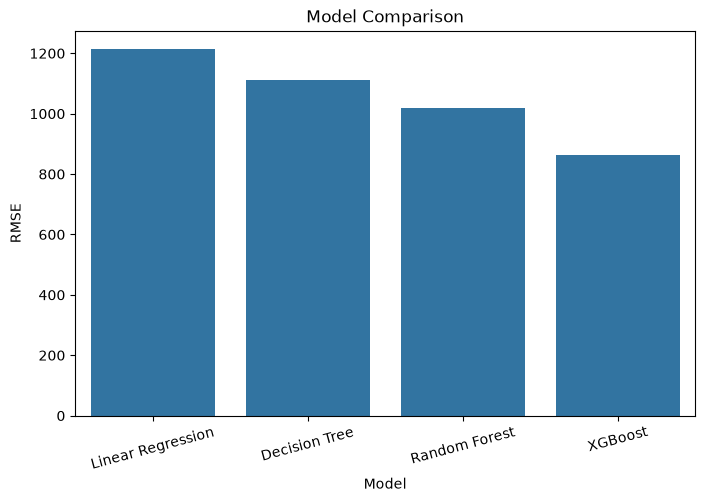

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=15)

plt.title("Model Comparison")

plt.show()

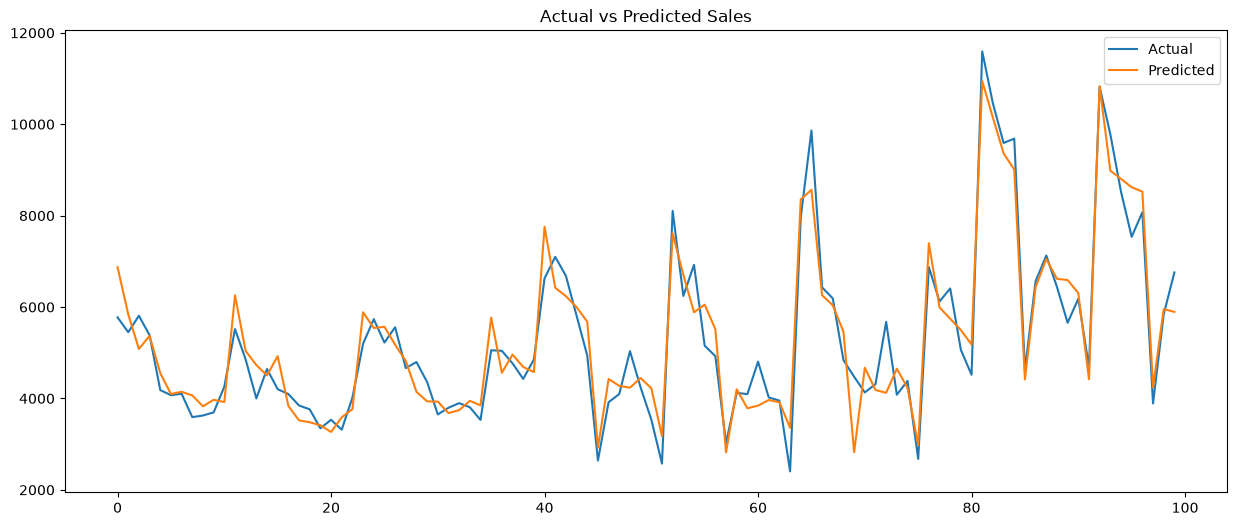

In [21]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    xgb_pred[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [22]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

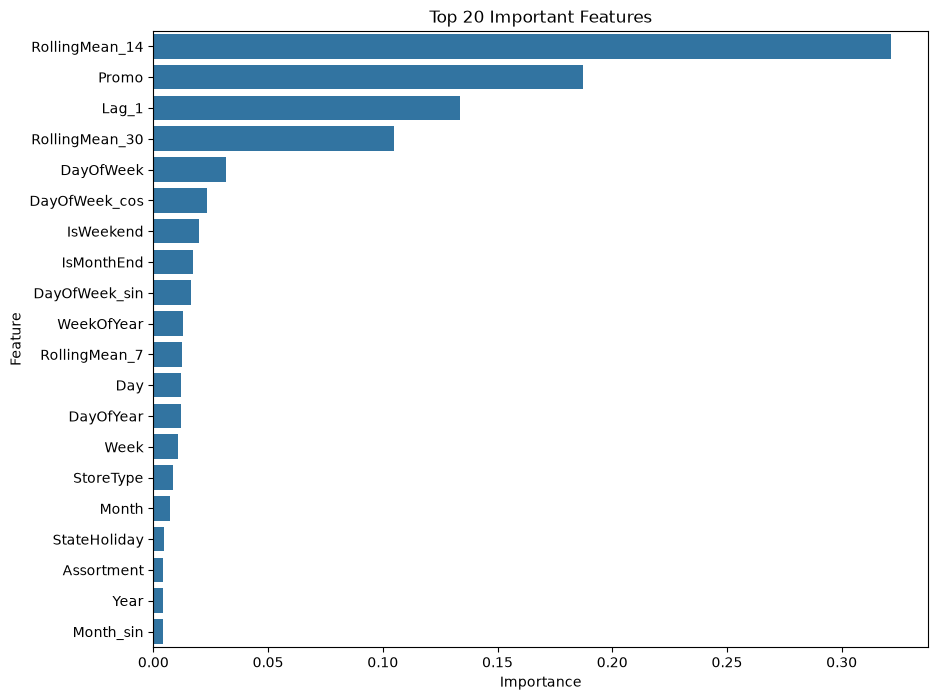

In [23]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

## Model Tunning

In [24]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
param_grid = {

    "n_estimators":[200,300,500,700],

    "max_depth":[4,6,8,10],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "min_child_weight":[1,3,5],

    "gamma":[0,0.1,0.2,0.3]

}

In [25]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [26]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=1,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [27]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=1,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.03, max_depth=10, min_child_weight=3, n_estimators=300, subsample=0.9; total time=  38.5s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.03, max_depth=10, min_child_weight=3, n_estimators=300, subsample=0.9; total time=  37.6s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.03, max_depth=10, min_child_weight=3, n_estimators=300, subsample=0.9; total time=  37.7s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...state=42, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a 

In [28]:
random_search.best_params_

{'subsample': 0.9,
 'n_estimators': 300,
 'min_child_weight': 3,
 'max_depth': 10,
 'learning_rate': 0.03,
 'gamma': 0.1,
 'colsample_bytree': 0.9}

In [29]:
best_xgb = random_search.best_estimator_

In [30]:
best_pred = best_xgb.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test,best_pred)

rmse = root_mean_squared_error(y_test,best_pred)

r2 = r2_score(y_test,best_pred)

In [32]:
comparison = pd.DataFrame({

    "Model":[
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "MAE":[
        xgb_mae,
        mae
    ],
    "RMSE":[
        xgb_rmse,
        rmse
    ],
    "R2":[
        xgb_r2,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Original XGBoost,614.019775,864.026245,0.924602
1,Tuned XGBoost,624.830627,884.974060,0.920902


## Explainability

In [42]:
import shap

In [43]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test.sample(100, random_state=42))

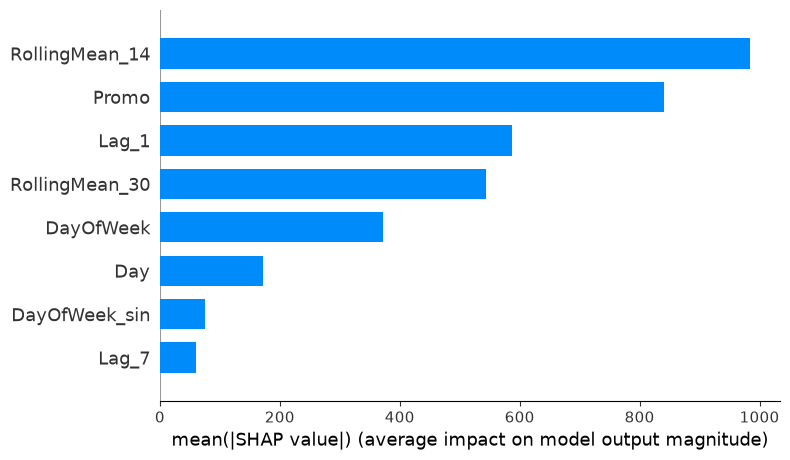

In [53]:
shap.summary_plot(
    shap_values,
    X_test.sample(100, random_state=42),
    plot_type="bar",
    max_display=8,
    show=False
)
plt.savefig("../assets/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

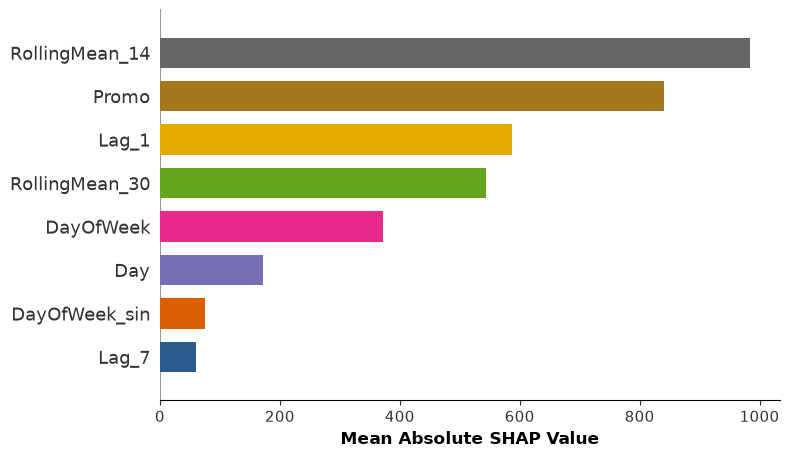

In [55]:
my_8_colors = [
    "#2b5c8f",  
    "#d95f02",  
    "#7570b3",  
    "#e7298a",  
    "#66a61e",  
    "#e6ab02",  
    "#a6761d",  
    "#666666",  
]

shap.summary_plot(
    shap_values,
    X_test.sample(100, random_state=42),
    plot_type="bar",
    max_display=8,
    show=False,
)

ax = plt.gca()

for patch, color in zip(ax.patches, my_8_colors):
    patch.set_facecolor(color)

ax.set_xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12,
    fontweight="bold",
)
plt.savefig("../assets/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

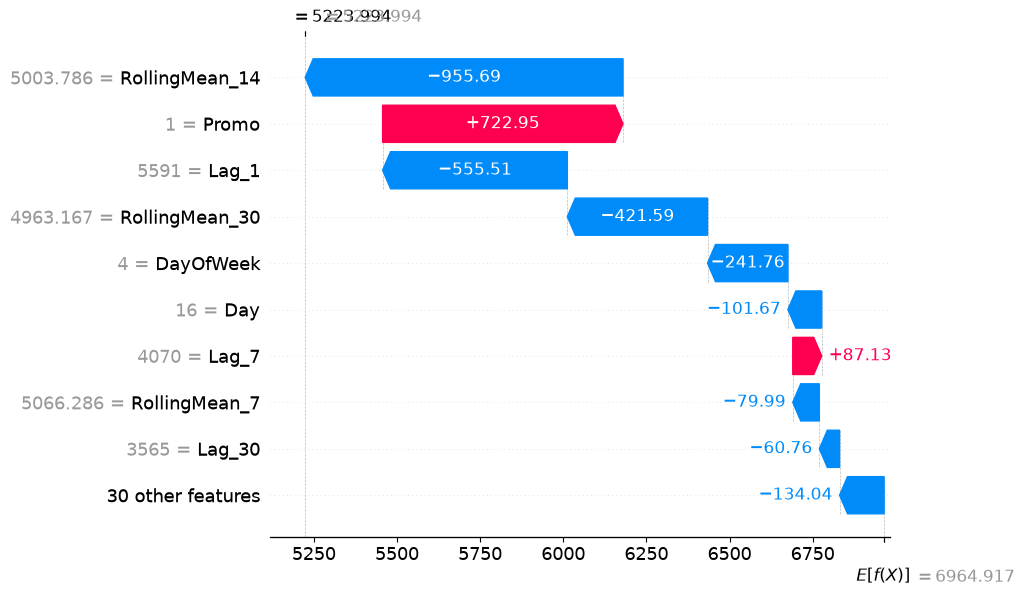

In [36]:
shap.plots.waterfall(shap_values[10])

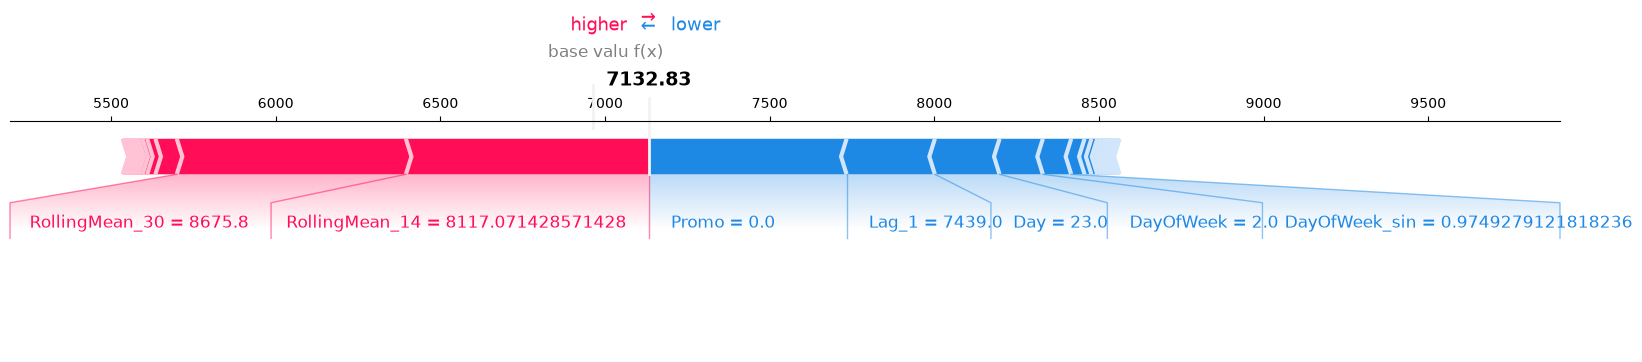

In [37]:
shap.plots.force(
    shap_values[0],
    matplotlib=True
)

In [38]:
importance.head(20).to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [47]:
joblib.dump(best_xgb, "../artifacts/xgboost_sales_forecast.pkl")

['../artifacts/xgboost_sales_forecast.pkl']

In [40]:
prediction_df = pd.DataFrame({

    "Date": X_test_date,

    "Actual":y_test,

    "Predicted":xgb_pred

})

prediction_df.to_csv(
    "../reports/predictions.csv",
    index=False
)

In [41]:
prediction_df = pd.DataFrame({
    "Store": X_test.Store,

    "Date": X_test_date,

    "Actual":y_test,

    "Predicted":xgb_pred

})

prediction_df.to_csv(
    "../reports/actual_predictions.csv",
    index=False
)

## Interpretation

Feature insights:
- `RollingMean_14` is the most important predictor, showing that recent two-week sales momentum is the key driver.
- `Promo` and `Lag_1` are also highly important, indicating that current promotions and yesterday’s sales strongly influence predictions.
- `RollingMean_30` and weekday/seasonal features contribute meaningfully, while competition-related variables are less influential.

SHAP interpretation:
- Recent sales history drives the largest positive and negative contributions to predictions.
- Promotional activity consistently boosts forecasted sales.
- Seasonal and store-specific patterns matter, especially day-of-week and month effects.
- Competition features have a smaller impact compared to the store’s own recent demand patterns.

Business takeaway:
- Forecasting should prioritize recent sales trends and promotional schedules.
- Planning should focus on maintaining stock and staffing around strong recent momentum and promotional periods.
- Competition is a factor, but internal sales history and promotions are the primary levers for accurate forecasting.